In [1]:
!pip install opencv-python-headless numpy matplotlib

import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import urllib.request
import os

# Configuración global de matplotlib
plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.titlesize'] = 11
plt.rcParams['axes.titleweight'] = 'bold'

print(' Librerías importadas correctamente')
print(f'   OpenCV  : {cv2.__version__}')
print(f'   NumPy   : {np.__version__}')

 Librerías importadas correctamente
   OpenCV  : 4.13.0
   NumPy   : 2.0.2


 Imagen descargada: imagen_taller.png

 Propiedades de la imagen:
   Shape (alto, ancho, canales) : (363, 740, 3)
   Tipo de dato                 : uint8
   Valor mínimo                 : 0
   Valor máximo                 : 255
   Total de píxeles             : 268,620


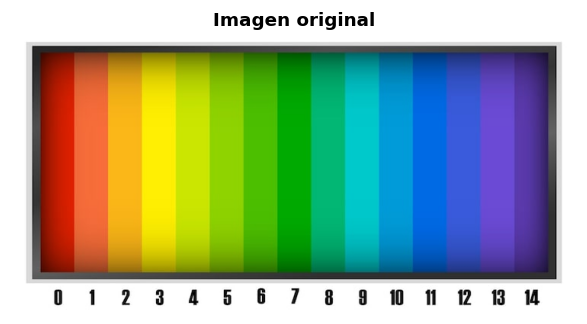

In [2]:
# --- Opción A: Descargar una imagen de ejemplo ---
url = 'https://img.magnific.com/vector-gratis/ilustracion-cientifica-espectro-colores_1308-177298.jpg?semt=ais_hybrid&w=740&q=80'
img_path = 'imagen_taller.png'

# Si prefieres usar tu propia imagen, comenta las siguientes líneas
# y define: img_path = 'ruta/a/tu/imagen.jpg'
urllib.request.urlretrieve(url, img_path)
print(f' Imagen descargada: {img_path}')

# --- Cargar con OpenCV ---
img_bgr = cv2.imread(img_path)

# Verificar que se cargó correctamente
if img_bgr is None:
    raise FileNotFoundError(f'No se pudo cargar la imagen: {img_path}')

# Convertir a RGB para visualización con matplotlib
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

print(f'\n Propiedades de la imagen:')
print(f'   Shape (alto, ancho, canales) : {img_bgr.shape}')
print(f'   Tipo de dato                 : {img_bgr.dtype}')
print(f'   Valor mínimo                 : {img_bgr.min()}')
print(f'   Valor máximo                 : {img_bgr.max()}')
print(f'   Total de píxeles             : {img_bgr.shape[0] * img_bgr.shape[1]:,}')

# Mostrar imagen
plt.figure(figsize=(5, 4))
plt.imshow(img_rgb)
plt.title('Imagen original')
plt.axis('off')
plt.tight_layout()
plt.show()

In [3]:
# Inspeccionar píxeles individuales
h, w, c = img_bgr.shape

print(' Valores de píxeles en posiciones específicas:')
print(f'   Esquina superior izquierda (0,0)     : BGR = {img_bgr[0, 0]}')
print(f'   Centro de la imagen ({h//2},{w//2})  : BGR = {img_bgr[h//2, w//2]}')
print(f'   Esquina inferior derecha ({h-1},{w-1}): BGR = {img_bgr[h-1, w-1]}')

print(f'\n Submatriz 4×4 del canal Verde (canal 1) en el centro:')
print(img_bgr[h//2-2:h//2+2, w//2-2:w//2+2, 1])

 Valores de píxeles en posiciones específicas:
   Esquina superior izquierda (0,0)     : BGR = [255 255 255]
   Centro de la imagen (181,370)  : BGR = [  1 170   0]
   Esquina inferior derecha (362,739): BGR = [255 255 255]

 Submatriz 4×4 del canal Verde (canal 1) en el centro:
[[170 170 170 170]
 [170 170 170 170]
 [170 170 170 170]
 [170 170 170 170]]


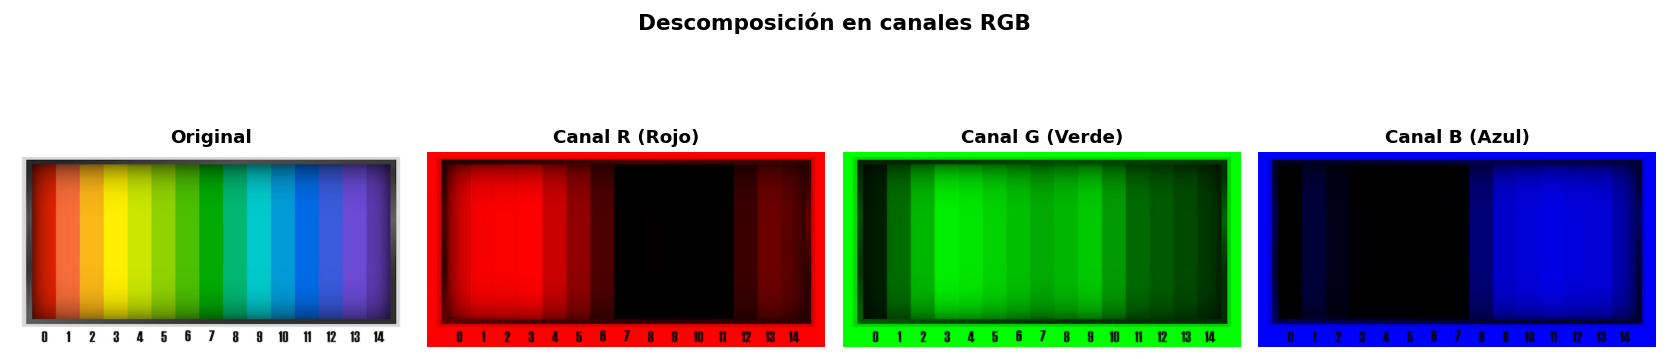

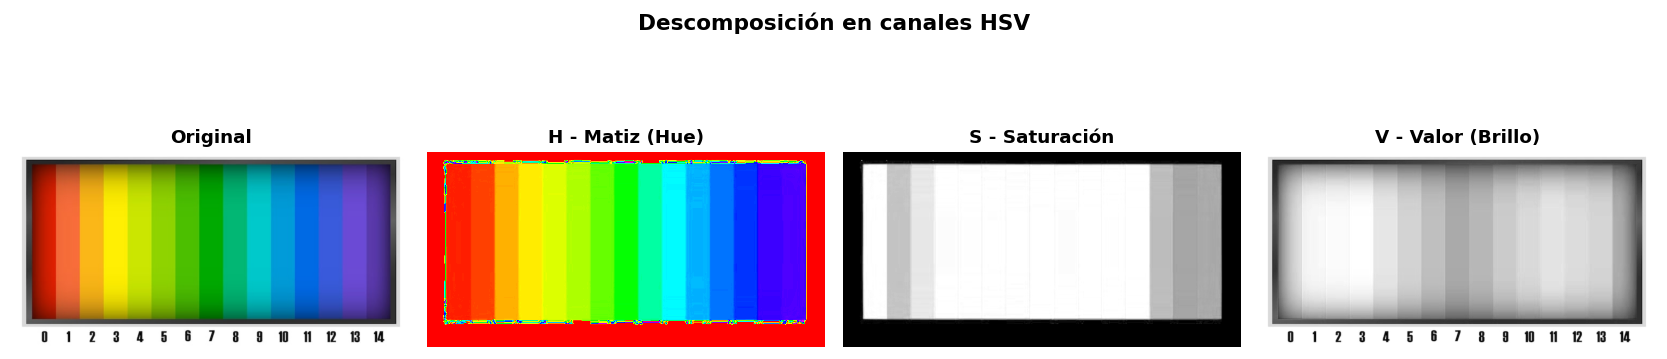

 HSV separa el COLOR (H) de la SATURACIÓN (S) y el BRILLO (V).
   Esto es muy útil para segmentación por color y ajustes de iluminación.


In [4]:
# ── Canales RGB ──────────────────────────────────────────────────────────────
r, g, b = img_rgb[:,:,0], img_rgb[:,:,1], img_rgb[:,:,2]

# Crear imágenes de canal único con color real
zeros = np.zeros_like(r)
img_rojo    = np.stack([r, zeros, zeros], axis=2)  # Solo rojo
img_verde   = np.stack([zeros, g, zeros], axis=2)  # Solo verde
img_azul    = np.stack([zeros, zeros, b], axis=2)  # Solo azul

fig, axes = plt.subplots(1, 4, figsize=(14, 3.5))
for ax, img, titulo in zip(axes,
                            [img_rgb, img_rojo, img_verde, img_azul],
                            ['Original', 'Canal R (Rojo)', 'Canal G (Verde)', 'Canal B (Azul)']):
    ax.imshow(img)
    ax.set_title(titulo)
    ax.axis('off')
plt.suptitle('Descomposición en canales RGB', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# ── Canales HSV ──────────────────────────────────────────────────────────────
img_hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)
h_ch, s_ch, v_ch = img_hsv[:,:,0], img_hsv[:,:,1], img_hsv[:,:,2]

fig, axes = plt.subplots(1, 4, figsize=(14, 3.5))
datos = [img_rgb, h_ch, s_ch, v_ch]
titulos = ['Original', 'H - Matiz (Hue)', 'S - Saturación', 'V - Valor (Brillo)']
cmaps = [None, 'hsv', 'gray', 'gray']

for ax, img, titulo, cmap in zip(axes, datos, titulos, cmaps):
    ax.imshow(img, cmap=cmap)
    ax.set_title(titulo)
    ax.axis('off')

plt.suptitle('Descomposición en canales HSV', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


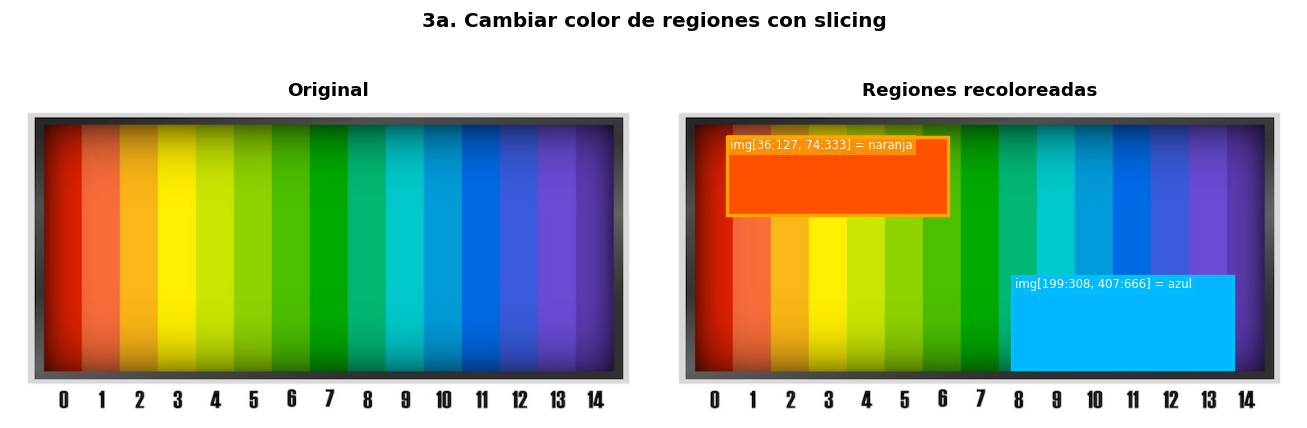


 Sintaxis utilizada:
   img[36:127, 74:333] = [255, 80, 0]    → región naranja
   img[199:308, 407:666] = [0, 180, 255]  → región azul


In [5]:
img_mod1 = img_rgb.copy()  # Siempre trabajar sobre una copia

h, w = img_mod1.shape[:2]

# Definir coordenadas del rectángulo (y1, y2, x1, x2)
y1, y2 = int(h * 0.10), int(h * 0.35)
x1, x2 = int(w * 0.10), int(w * 0.45)

# Pintar la región de un color sólido (RGB)
color_nuevo = [255, 80, 0]   # Naranja
img_mod1[y1:y2, x1:x2] = color_nuevo

# Agregar un segundo rectángulo de diferente color
y3, y4 = int(h * 0.55), int(h * 0.85)
x3, x4 = int(w * 0.55), int(w * 0.90)
img_mod1[y3:y4, x3:x4] = [0, 180, 255]  # Azul cielo

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].imshow(img_rgb)
axes[0].set_title('Original')
axes[0].axis('off')
axes[1].imshow(img_mod1)
axes[1].set_title('Regiones recoloreadas')

# Anotar las regiones
import matplotlib.patches as mpatches
for (px1, py1, px2, py2, color, label) in [
        (x1, y1, x2-x1, y2-y1, 'orange', f'img[{y1}:{y2}, {x1}:{x2}] = naranja'),
        (x3, y3, x4-x3, y4-y3, 'deepskyblue', f'img[{y3}:{y4}, {x3}:{x4}] = azul')]:
    rect = mpatches.FancyBboxPatch((px1, py1), px2, py2,
                                    boxstyle='square,pad=0', linewidth=2,
                                    edgecolor=color, facecolor='none')
    axes[1].add_patch(rect)
    axes[1].text(px1+4, py1+14, label, color='white', fontsize=7,
                 bbox=dict(facecolor=color, alpha=0.75, pad=2, edgecolor='none'))

axes[1].axis('off')
plt.suptitle('3a. Cambiar color de regiones con slicing', fontweight='bold')
plt.tight_layout()
plt.show()

print(f'\n Sintaxis utilizada:')
print(f'   img[{y1}:{y2}, {x1}:{x2}] = [255, 80, 0]    → región naranja')
print(f'   img[{y3}:{y4}, {x3}:{x4}] = [0, 180, 255]  → región azul')

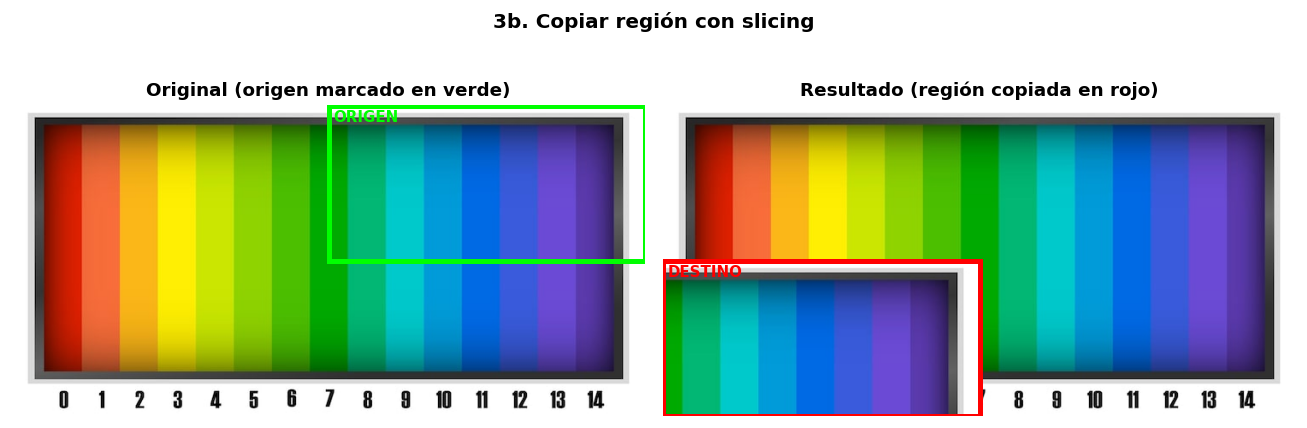

 Sintaxis:
   region_origen = img[0:181, 370:740].copy()
   img[181:363, 0:370] = region_origen


In [6]:
img_mod2 = img_rgb.copy()

h, w = img_mod2.shape[:2]

# Región ORIGEN: cuadrante superior derecho
src_y1, src_y2 = 0, h // 2
src_x1, src_x2 = w // 2, w
region_origen = img_rgb[src_y1:src_y2, src_x1:src_x2].copy()

# Región DESTINO: cuadrante inferior izquierdo (mismo tamaño)
dst_y1, dst_y2 = h // 2, h
dst_x1, dst_x2 = 0, w // 2

# Redimensionar si los tamaños no coinciden exactamente
dst_h = dst_y2 - dst_y1
dst_w = dst_x2 - dst_x1
region_origen_resized = cv2.resize(region_origen, (dst_w, dst_h))

#  Operación de copia por slicing
img_mod2[dst_y1:dst_y2, dst_x1:dst_x2] = region_origen_resized

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].imshow(img_rgb)
# Marcar regiones en el original
src_rect = mpatches.FancyBboxPatch((src_x1, src_y1), src_x2-src_x1, src_y2-src_y1,
                                    boxstyle='square,pad=0', linewidth=3,
                                    edgecolor='lime', facecolor='none')
axes[0].add_patch(src_rect)
axes[0].text(src_x1+5, src_y1+18, 'ORIGEN', color='lime', fontsize=9, fontweight='bold')
axes[0].set_title('Original (origen marcado en verde)')
axes[0].axis('off')

axes[1].imshow(img_mod2)
dst_rect = mpatches.FancyBboxPatch((dst_x1, dst_y1), dst_x2-dst_x1, dst_y2-dst_y1,
                                    boxstyle='square,pad=0', linewidth=3,
                                    edgecolor='red', facecolor='none')
axes[1].add_patch(dst_rect)
axes[1].text(dst_x1+5, dst_y1+18, 'DESTINO', color='red', fontsize=9, fontweight='bold')
axes[1].set_title('Resultado (región copiada en rojo)')
axes[1].axis('off')

plt.suptitle('3b. Copiar región con slicing', fontweight='bold')
plt.tight_layout()
plt.show()

print(' Sintaxis:')
print(f'   region_origen = img[{src_y1}:{src_y2}, {src_x1}:{src_x2}].copy()')
print(f'   img[{dst_y1}:{dst_y2}, {dst_x1}:{dst_x2}] = region_origen')

   Canal Rojo (R)    : μ =  125.7  σ =  99.2  min=0  max=255
   Canal Verde (G)   : μ =  152.8  σ =  74.7  min=0  max=255
   Canal Azul (B)    : μ =  118.4  σ = 100.5  min=0  max=255


C:\Users\famil\AppData\Local\Temp\ipykernel_18424\153291992.py:38: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


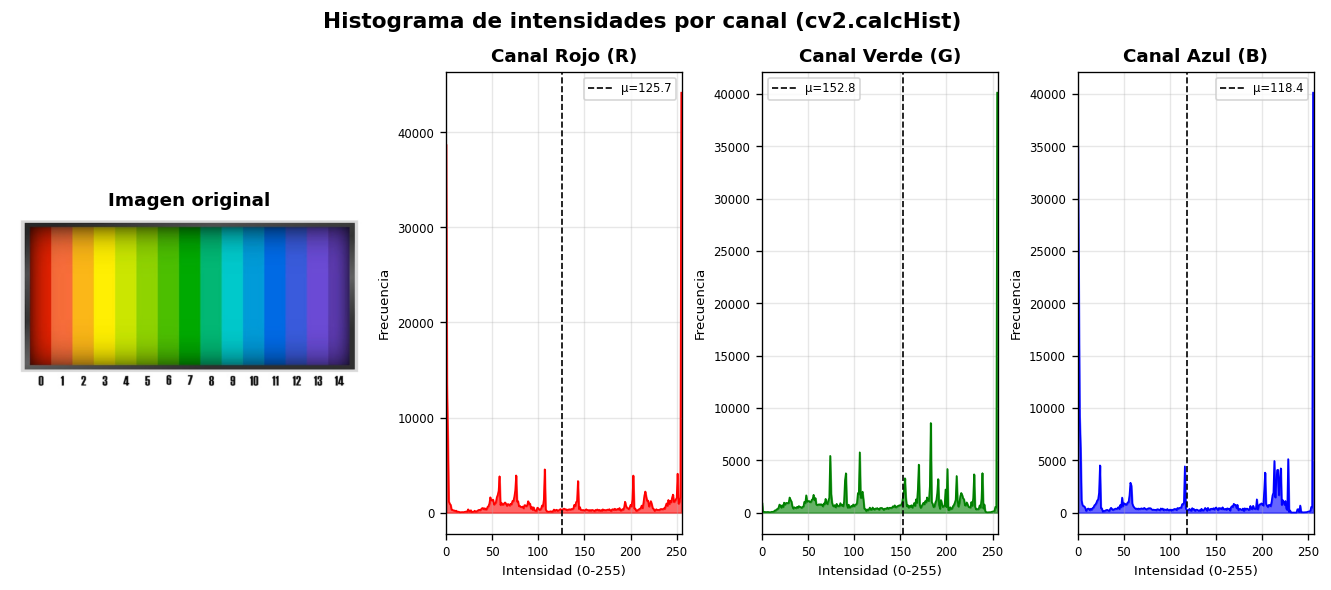

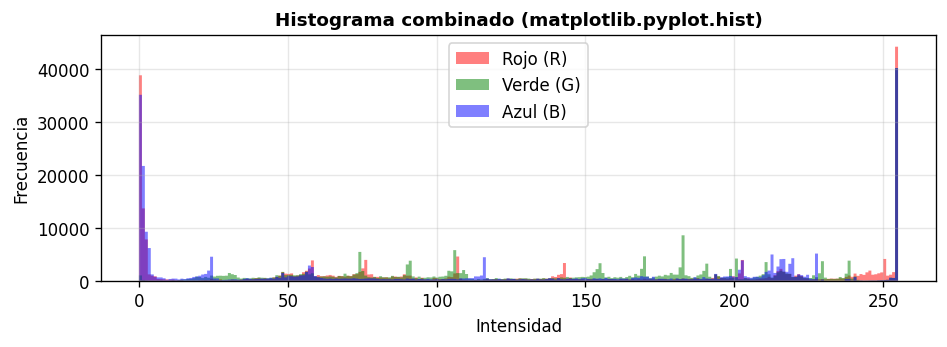

In [7]:
colores_rgb  = ['red', 'green', 'blue']
nombres_canal = ['Rojo (R)', 'Verde (G)', 'Azul (B)']

fig = plt.figure(figsize=(14, 5))
gs = gridspec.GridSpec(1, 4, width_ratios=[1.5, 1, 1, 1], wspace=0.3)

# Imagen original
ax0 = fig.add_subplot(gs[0])
ax0.imshow(img_rgb)
ax0.set_title('Imagen original', fontweight='bold')
ax0.axis('off')

# Histograma por canal
for i, (color, nombre) in enumerate(zip(colores_rgb, nombres_canal)):
    ax = fig.add_subplot(gs[i + 1])

    # Método 1: cv2.calcHist
    hist_cv2 = cv2.calcHist([img_bgr], [2 - i], None, [256], [0, 256])
    ax.fill_between(range(256), hist_cv2.flatten(), alpha=0.6, color=color)
    ax.plot(hist_cv2.flatten(), color=color, linewidth=1)

    ax.set_title(f'Canal {nombre}', fontweight='bold')
    ax.set_xlabel('Intensidad (0-255)', fontsize=8)
    ax.set_ylabel('Frecuencia', fontsize=8)
    ax.set_xlim([0, 256])
    ax.tick_params(labelsize=7)
    ax.grid(True, alpha=0.3)

    # Estadísticas
    canal_data = img_rgb[:,:,i]
    media = canal_data.mean()
    std   = canal_data.std()
    ax.axvline(media, color='black', linestyle='--', linewidth=1, label=f'μ={media:.1f}')
    ax.legend(fontsize=7)
    print(f'   Canal {nombre:12s}: μ = {media:6.1f}  σ = {std:5.1f}  min={canal_data.min()}  max={canal_data.max()}')

plt.suptitle('Histograma de intensidades por canal (cv2.calcHist)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# ── Histograma combinado con matplotlib.hist ──────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 3))
for i, (color, nombre) in enumerate(zip(colores_rgb, nombres_canal)):
    ax.hist(img_rgb[:,:,i].ravel(), bins=256, range=(0,255),
            color=color, alpha=0.5, label=nombre, histtype='stepfilled')
ax.set_title('Histograma combinado (matplotlib.pyplot.hist)', fontweight='bold')
ax.set_xlabel('Intensidad')
ax.set_ylabel('Frecuencia')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

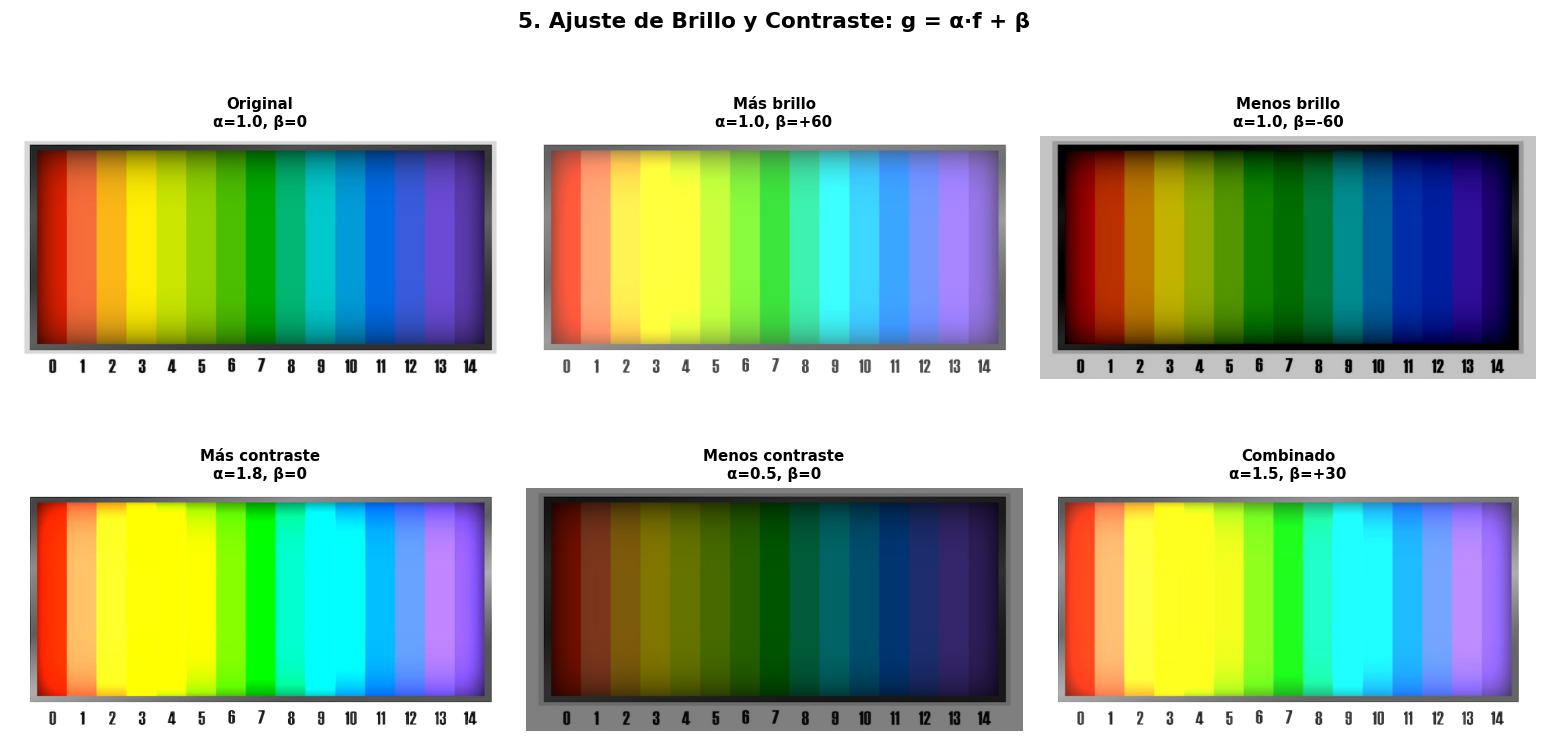


 Diferencia máxima entre método manual y cv2.convertScaleAbs: 1 píxeles


In [8]:
def ajustar_brillo_contraste(imagen_rgb, alpha=1.0, beta=0):
    """
    Aplica: g = alpha * f + beta
    
    Args:
        imagen_rgb : imagen NumPy en formato RGB
        alpha      : factor de contraste (default 1.0 = sin cambio)
        beta       : ajuste de brillo en [-127, 127]
    Returns:
        imagen ajustada (uint8, valores clipeados a [0,255])
    """
    # Método 1: Ecuación manual con NumPy
    img_manual = np.clip(alpha * imagen_rgb.astype(np.float32) + beta, 0, 255).astype(np.uint8)

    # Método 2: OpenCV (equivalente, más eficiente)
    img_cv2 = cv2.convertScaleAbs(imagen_rgb, alpha=alpha, beta=beta)

    return img_manual, img_cv2


# ── Comparación de diferentes ajustes ────────────────────────────────────────
configs = [
    (1.0,   0,  'Original\nα=1.0, β=0'),
    (1.0,  60,  'Más brillo\nα=1.0, β=+60'),
    (1.0, -60,  'Menos brillo\nα=1.0, β=-60'),
    (1.8,   0,  'Más contraste\nα=1.8, β=0'),
    (0.5,   0,  'Menos contraste\nα=0.5, β=0'),
    (1.5,  30,  'Combinado\nα=1.5, β=+30'),
]

fig, axes = plt.subplots(2, 3, figsize=(13, 7))
axes = axes.flatten()

for ax, (alpha, beta, titulo) in zip(axes, configs):
    img_result, _ = ajustar_brillo_contraste(img_rgb, alpha=alpha, beta=beta)
    ax.imshow(img_result)
    ax.set_title(titulo, fontsize=9)
    ax.axis('off')

plt.suptitle('5. Ajuste de Brillo y Contraste: g = α·f + β', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# ── Verificar equivalencia entre métodos ────────────────────────────────────
img_m, img_c = ajustar_brillo_contraste(img_rgb, alpha=1.5, beta=30)
diferencia = np.abs(img_m.astype(int) - img_c.astype(int)).max()
print(f'\n Diferencia máxima entre método manual y cv2.convertScaleAbs: {diferencia} píxeles')

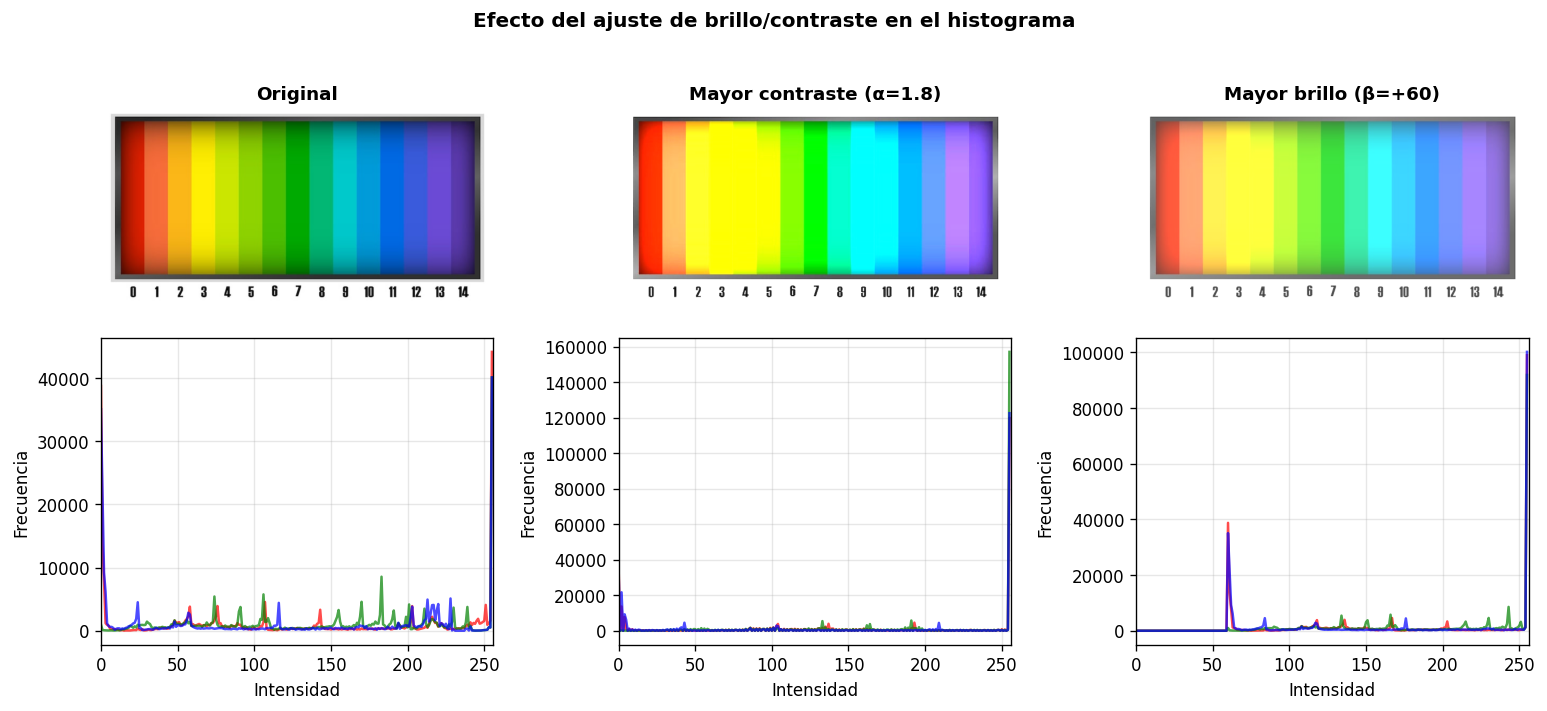

In [9]:
casos = [
    (img_rgb, 'Original'),
    (cv2.convertScaleAbs(img_rgb, alpha=1.8, beta=0), 'Mayor contraste (α=1.8)'),
    (cv2.convertScaleAbs(img_rgb, alpha=1.0, beta=60), 'Mayor brillo (β=+60)'),
]

fig, axes = plt.subplots(2, 3, figsize=(13, 6))

for col, (img, titulo) in enumerate(casos):
    axes[0, col].imshow(img)
    axes[0, col].set_title(titulo, fontweight='bold')
    axes[0, col].axis('off')

    # Histograma de los 3 canales
    for i, color in enumerate(['red', 'green', 'blue']):
        hist = cv2.calcHist([img], [i], None, [256], [0, 256])
        axes[1, col].plot(hist, color=color, alpha=0.7)
    axes[1, col].set_xlim([0, 256])
    axes[1, col].set_xlabel('Intensidad')
    axes[1, col].set_ylabel('Frecuencia')
    axes[1, col].grid(True, alpha=0.3)

plt.suptitle('Efecto del ajuste de brillo/contraste en el histograma', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

In [10]:
try:
    import ipywidgets as widgets
    from IPython.display import display

    # Sliders
    slider_alpha = widgets.FloatSlider(
        value=1.0, min=0.1, max=3.0, step=0.1,
        description='Contraste (α):',
        style={'description_width': '130px'},
        layout=widgets.Layout(width='500px')
    )
    slider_beta = widgets.IntSlider(
        value=0, min=-127, max=127, step=5,
        description='Brillo (β):',
        style={'description_width': '130px'},
        layout=widgets.Layout(width='500px')
    )
    output = widgets.Output()

    def actualizar(alpha, beta):
        img_ajustada = cv2.convertScaleAbs(img_rgb, alpha=alpha, beta=beta)

        with output:
            output.clear_output(wait=True)
            fig, axes = plt.subplots(1, 2, figsize=(11, 4))

            axes[0].imshow(img_rgb)
            axes[0].set_title('Original')
            axes[0].axis('off')

            axes[1].imshow(img_ajustada)
            axes[1].set_title(f'Ajustada: α={alpha:.1f}, β={beta:+d}')
            axes[1].axis('off')

            plt.suptitle(' Control interactivo de brillo y contraste',
                         fontweight='bold', fontsize=12)
            plt.tight_layout()
            plt.show()

    interactive = widgets.interactive(actualizar,
                                      alpha=slider_alpha,
                                      beta=slider_beta)
    display(widgets.VBox([slider_alpha, slider_beta, output]))
    actualizar(1.0, 0)  # Mostrar estado inicial

except ImportError:
    print(' ipywidgets no está disponible. Instalarlo con:')
    print('   pip install ipywidgets')
    print('   jupyter nbextension enable --py widgetsnbextension')

 Widgets cargados. Mueve los sliders para ajustar en tiempo real.
